In [1]:
# Import statements
import os
import argparse
import matplotlib
import numpy as py
from plantcv import plantcv as pcv

In [2]:
class options:
    def __init__(self):
        self.image = "Plant_leave_diseases_dataset_without_augmentation/Apple___Apple_scab/image (1).JPG"
        self.debug = "plot"
        self.writeimg = False
        self.result = ""
        self.outdir = "."
args = options()
pcv.params.debug_outdir = args.outdir
pcv.params.debug = args.debug

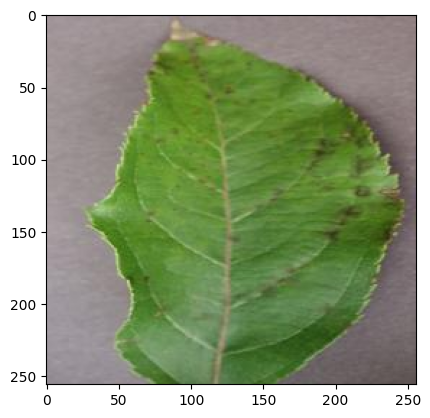

In [25]:
# Read the image
img, path, filename = pcv.readimage(args.image, mode="rgb")

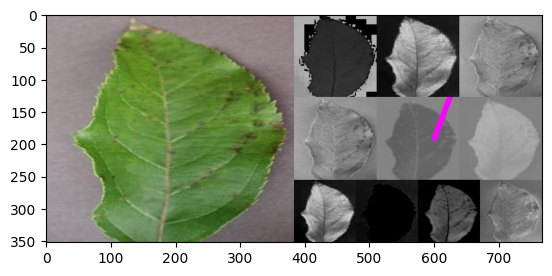

In [21]:
# Update params

pcv.params.text_size = 50
pcv.params.text_thickness = 15

colorspace = pcv.visualize.colorspaces(rgb_img=img)

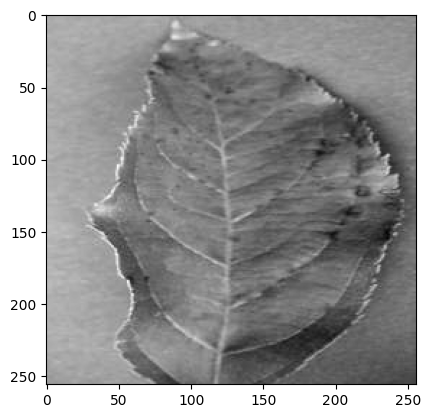

In [26]:
# RGB To Gray Scale Conversion
a = pcv.rgb2gray(rgb_img=img)

In [27]:
# Histogram of unequalized gray scale image
hist = pcv.visualize.histogram(a)

alt.Chart(...)

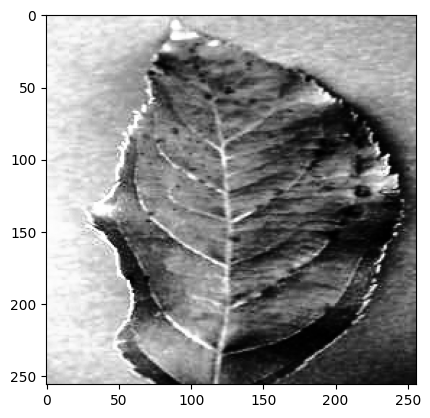

In [30]:
# Histogram Equalization
a_equalized = pcv.hist_equalization(a)

In [31]:
# Histogram Of Equalized Gray Scale Image
a_equalized_histogram = pcv.visualize.histogram(a_equalized)

alt.Chart(...)

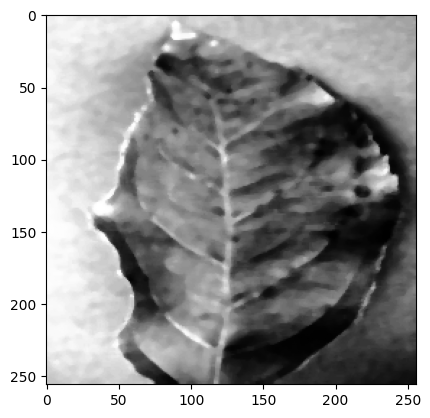

In [32]:
# Median Filtering
a_equalized_with_median_filtering = pcv.median_blur(a_equalized, 5)

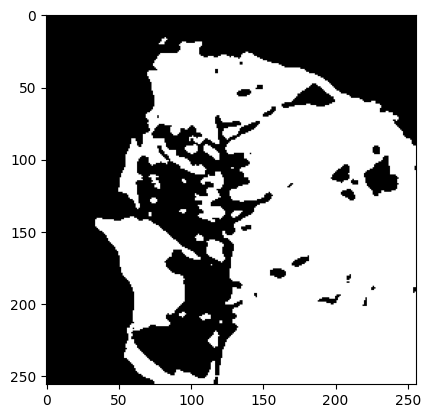

In [39]:
# Segmentation With Otsu Method
segmented_image_with_otsu = pcv.threshold.otsu(a_equalized_with_median_filtering, object_type="dark")

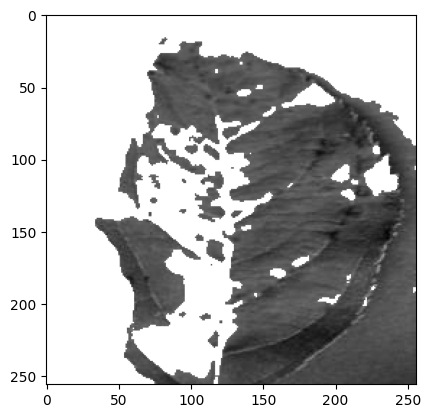

In [40]:
# Apply Mask From Otsu Method
background_removed_using_mask = pcv.apply_mask(img=a, mask=segmented_image_with_otsu, mask_color="white")

In [ ]:
# Problems, I need to perform morphological operations to the mask so it is more accurate

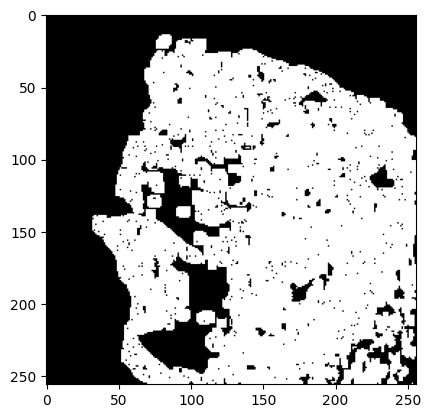

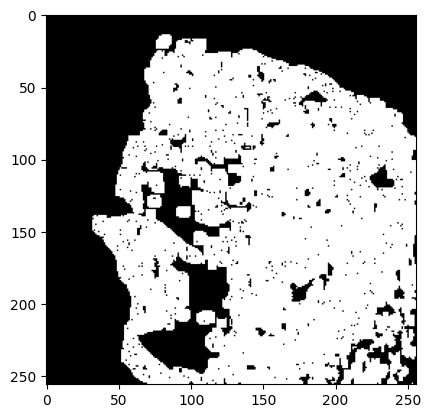

<class 'numpy.ndarray'>


In [46]:
# Obtain gray-level co-occurence matrix
texture_img = pcv.threshold.texture(gray_img=background_removed_using_mask, ksize=6, threshold=7, offset=3, texture_method='contrast', borders='nearest')